# 01 -- Exploratory Data Analysis

Full 6-year (2018-2023) CMS Medicare Physician & Other Practitioners dataset, 58.9M service-line records. Everything below is queried live from `data/cms_medicare.duckdb` -- no numbers are hardcoded.

In [1]:
import sys
sys.path.insert(0, "../src")
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
con = duckdb.connect("../data/cms_medicare.duckdb", read_only=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## Row counts by layer and year

In [2]:
con.execute("""
SELECT source_year, COUNT(*) AS bronze_rows
FROM bronze_physician_service GROUP BY 1 ORDER BY 1
""").fetchdf()

,source_year,bronze_rows
0,2018,9961865
1,2019,10140228
2,2020,9449361
3,2021,9886177
4,2022,9755427
5,2023,9660647


In [3]:
con.execute("""
SELECT source_year, COUNT(*) AS silver_rows,
       COUNT(DISTINCT rendering_npi) AS distinct_providers
FROM silver_physician_service GROUP BY 1 ORDER BY 1
""").fetchdf()

,source_year,silver_rows,distinct_providers
0,2018,9961865,1061278
1,2019,10140228,1093367
2,2020,9449361,1085313
3,2021,9886177,1123589
4,2022,9755427,1148873
5,2023,9660647,1175281


## Medicare payments over time

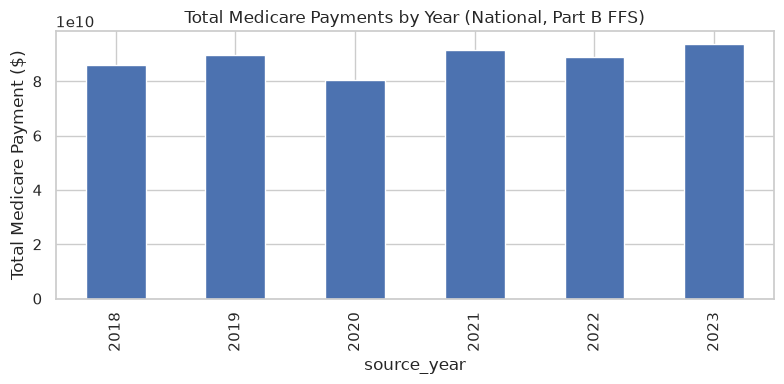

In [4]:
df = con.execute("""
SELECT source_year, SUM(provider_total_medicare_payment) AS total_payment
FROM gold_provider_year GROUP BY 1 ORDER BY 1
""").fetchdf()
ax = df.plot(x="source_year", y="total_payment", kind="bar", legend=False, figsize=(8,4))
ax.set_ylabel("Total Medicare Payment ($)")
ax.set_title("Total Medicare Payments by Year (National, Part B FFS)")
plt.tight_layout(); plt.show()

## Distribution of provider-level annual payment (log scale)

Heavily right-skewed, as expected for healthcare cost data -- a small number of large organizational providers account for a disproportionate share of spend. This skew is why Model 1 predicts `log1p(payment)`.

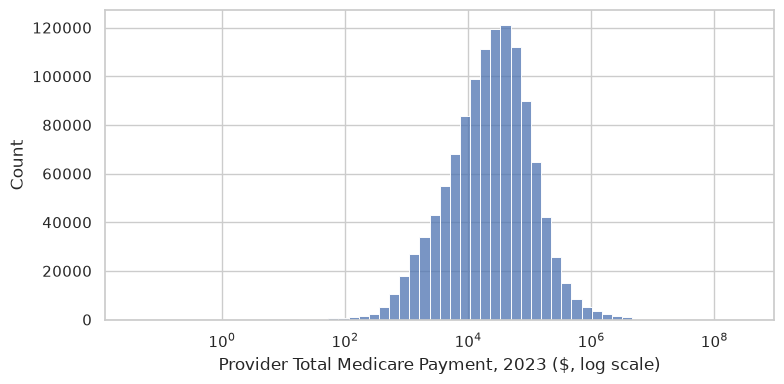

In [5]:
df = con.execute("""
SELECT provider_total_medicare_payment FROM gold_provider_year
WHERE source_year = 2023 AND provider_total_medicare_payment > 0
""").fetchdf()
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(df["provider_total_medicare_payment"], log_scale=True, bins=60, ax=ax)
ax.set_xlabel("Provider Total Medicare Payment, 2023 ($, log scale)")
plt.tight_layout(); plt.show()

## Top 15 specialties by total payment (2023)

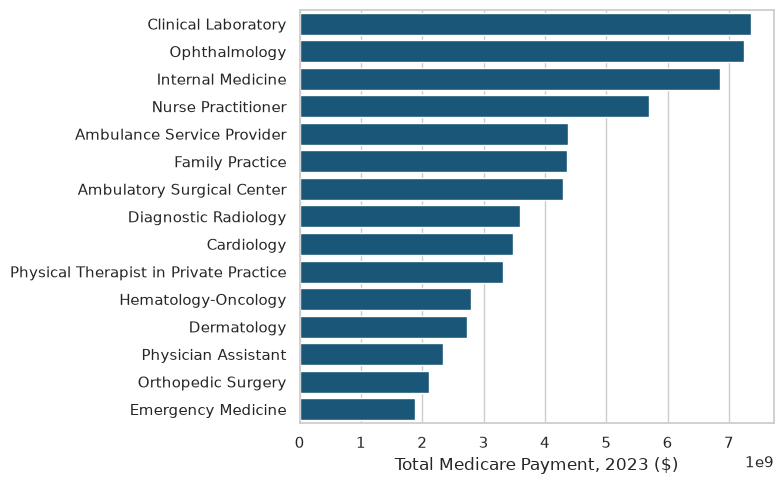

In [6]:
df = con.execute("""
SELECT provider_specialty, SUM(provider_total_medicare_payment) AS total_payment
FROM gold_provider_year WHERE source_year = 2023
GROUP BY 1 ORDER BY 2 DESC LIMIT 15
""").fetchdf()
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(df, y="provider_specialty", x="total_payment", ax=ax, color="#0B5A86")
ax.set_xlabel("Total Medicare Payment, 2023 ($)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## Top 15 states by total payment (2023)

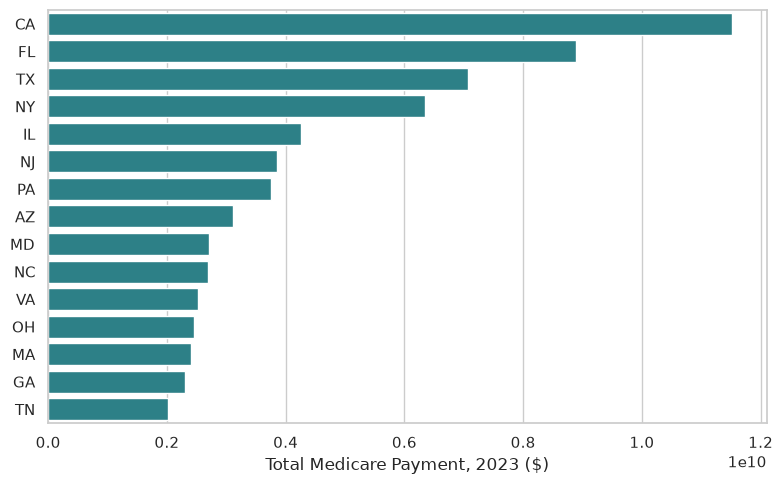

In [7]:
df = con.execute("""
SELECT provider_state, SUM(provider_total_medicare_payment) AS total_payment
FROM gold_provider_year WHERE source_year = 2023 AND provider_state IS NOT NULL
GROUP BY 1 ORDER BY 2 DESC LIMIT 15
""").fetchdf()
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(df, y="provider_state", x="total_payment", ax=ax, color="#1E8C96")
ax.set_xlabel("Total Medicare Payment, 2023 ($)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## Missingness check (Silver layer, all 6 years)

Zero nulls on every key field -- see `reports/data_limitations.md` for why (CMS *omits* suppressed rows rather than nulling fields).

In [8]:
con.execute("""
SELECT
  SUM((provider_specialty IS NULL)::INT) AS null_specialty,
  SUM((provider_state IS NULL OR provider_state='')::INT) AS null_state,
  SUM((total_beneficiaries IS NULL)::INT) AS null_benes,
  SUM((avg_medicare_payment_amt IS NULL)::INT) AS null_payment,
  COUNT(*) AS total_rows
FROM silver_physician_service
""").fetchdf()

,null_specialty,null_state,null_benes,null_payment,total_rows
0,0.00,0.00,0.00,0.00,58853705


## Suppression proximity

Rows within CMS's beneficiary-count suppression threshold (`< 11`) are flagged, not fabricated -- rows *below* the threshold are entirely absent from the source file to begin with.

In [9]:
con.execute("""
SELECT source_year,
       SUM(is_near_suppression_threshold::INT) AS near_threshold_lines,
       COUNT(*) AS total_lines,
       ROUND(100.0 * SUM(is_near_suppression_threshold::INT) / COUNT(*), 2) AS pct
FROM silver_physician_service GROUP BY 1 ORDER BY 1
""").fetchdf()

,source_year,near_threshold_lines,total_lines,pct
0,2018,0.00,9961865,0.00
1,2019,0.00,10140228,0.00
2,2020,0.00,9449361,0.00
3,2021,0.00,9886177,0.00
4,2022,0.00,9755427,0.00
5,2023,0.00,9660647,0.00
